In [ ]:
!pip install ta


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=b23555031270bbd2d96bf00239b40f9432aa9392c8eff65eb439d95c4b711a25
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error
import ta
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import requests


url = 'https://www.alphavantage.co/query?function=DIGITAL_CURRENCY_DAILY&symbol=BTC&market=USD&apikey=IMC7MNTFRJNI2QX2'
r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Daily Prices and Volumes for Digital Currency', '2. Digital Currency Code': 'BTC', '3. Digital Currency Name': 'Bitcoin', '4. Market Code': 'USD', '5. Market Name': 'United States Dollar', '6. Last Refreshed': '2026-04-11 00:00:00', '7. Time Zone': 'UTC'}, 'Time Series (Digital Currency Daily)': {'2026-04-11': {'1. open': '72997.88000000', '2. high': '72997.88000000', '3. low': '72846.65000000', '4. close': '72916.45000000', '5. volume': '52.89758156'}, '2026-04-10': {'1. open': '71798.01000000', '2. high': '73477.87000000', '3. low': '71431.55000000', '4. close': '72997.88000000', '5. volume': '10066.64303661'}, '2026-04-09': {'1. open': '71083.99000000', '2. high': '73147.81000000', '3. low': '70468.74000000', '4. close': '71798.01000000', '5. volume': '10707.78813462'}, '2026-04-08': {'1. open': '71910.21000000', '2. high': '72861.38000000', '3. low': '70684.65000000', '4. close': '71085.99000000', '5. volume': '11083.24086941'}, '2026-04-07': {'1. 

In [ ]:
import pandas as pd
raw= data['Time Series (Digital Currency Daily)']
raw

df = pd.DataFrame(raw).T


df.head()

,1. open,2. high,3. low,4. close,5. volume
2026-04-11,72997.88000000,72997.88000000,72846.65000000,72916.45000000,52.89758156
2026-04-10,71798.01000000,73477.87000000,71431.55000000,72997.88000000,10066.64303661
2026-04-09,71083.99000000,73147.81000000,70468.74000000,71798.01000000,10707.78813462
2026-04-08,71910.21000000,72861.38000000,70684.65000000,71085.99000000,11083.24086941
2026-04-07,68853.60000000,72753.97000000,67710.01000000,71910.20000000,11156.72732306


In [ ]:
df.columns = [
    'open', 'high',
    'low', 'close',
    'volume'
]

df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.isnull().sum()
df = df.astype(float)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5748 entries, 2010-07-17 to 2026-04-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5748 non-null   float64
 1   high    5748 non-null   float64
 2   low     5748 non-null   float64
 3   close   5748 non-null   float64
 4   volume  5748 non-null   float64
dtypes: float64(5)
memory usage: 269.4 KB


,open,high,low,close,volume
2010-07-17,0.0500,0.0500,0.0500,0.0500,0.000000
2010-07-18,0.0858,0.0858,0.0858,0.0858,0.000000
2010-07-19,0.0808,0.0808,0.0808,0.0808,0.000000
2010-07-20,0.0747,0.0747,0.0747,0.0747,0.000000
2010-07-21,0.0792,0.0792,0.0792,0.0792,0.000000
...,...,...,...,...,...
2026-04-07,68853.6000,72753.9700,67710.0100,71910.2000,11156.727323
2026-04-08,71910.2100,72861.3800,70684.6500,71085.9900,11083.240869
2026-04-09,71083.9900,73147.8100,70468.7400,71798.0100,10707.788135
2026-04-10,71798.0100,73477.8700,71431.5500,72997.8800,10066.643037


In [ ]:
df['MA10'] = ta.trend.sma_indicator(df['close'], window=10)
df['MA50'] = ta.trend.sma_indicator(df['close'], window=50)

# Exponential moving averages
df['EMA10'] = ta.trend.ema_indicator(df['close'], window=10)

# MACD
macd = ta.trend.MACD(df['close'])
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()
df['MACD_diff'] = macd.macd_diff()

# RSI
df['RSI14'] = ta.momentum.rsi(df['close'], window=14)

# ATR (Average True Range) - volatility
df['ATR14'] = ta.volatility.average_true_range(df['high'], df['low'], df['close'], window=14)

# OBV (On-Balance Volume)
df['OBV'] = ta.volume.on_balance_volume(df['close'], df['volume'])

# Rolling statistics (window 5 and 20)
df['close_roll_mean_5'] = df['close'].rolling(5).mean()
df['close_roll_std_5'] = df['close'].rolling(5).std()
df['close_roll_mean_20'] = df['close'].rolling(20).mean()
df['close_roll_std_20'] = df['close'].rolling(20).std()

# Day of week (sin/cos encoding)
df['dayofweek'] = df.index.dayofweek
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)


# Feature for the Model: Bollinger %B
# This normalizes the bands into a 0-to-1 scale
# 1. Middle Band (20-day Moving Average)
df['MA20'] = df['close'].rolling(window=20).mean()

# 2. 20-day Standard Deviation (The "Risk" measure)
df['20STD'] = df['close'].rolling(window=20).std()

df['Upper_Band'] = df['MA20'] + (df['20STD'] * 2)
df['Lower_Band'] = df['MA20'] - (df['20STD'] * 2)

df['Bollinger_PercB'] = (df['close'] - df['Lower_Band']) / (df['Upper_Band'] - df['Lower_Band'])


In [ ]:
df['return'] = df['close'].pct_change()
df = df.dropna()
df

feature_cols = [
    'volume',
    'MA50',
    'MACD', 'MACD_signal', 'MACD_diff',
    'RSI14', 'ATR14', 'OBV',
    'close_roll_std_5',
    'close_roll_mean_20',

    'dayofweek_sin', 'dayofweek_cos', 'Bollinger_PercB'
]

X= df[feature_cols].values
X
y= df['return']
y



,return
2010-09-04,0.024631
2010-09-05,-0.012821
2010-09-06,0.000000
2010-09-07,-0.009740
2010-09-08,0.016393
...,...
2026-04-07,0.044393
2026-04-08,-0.011462
2026-04-09,0.010016
2026-04-10,0.016712


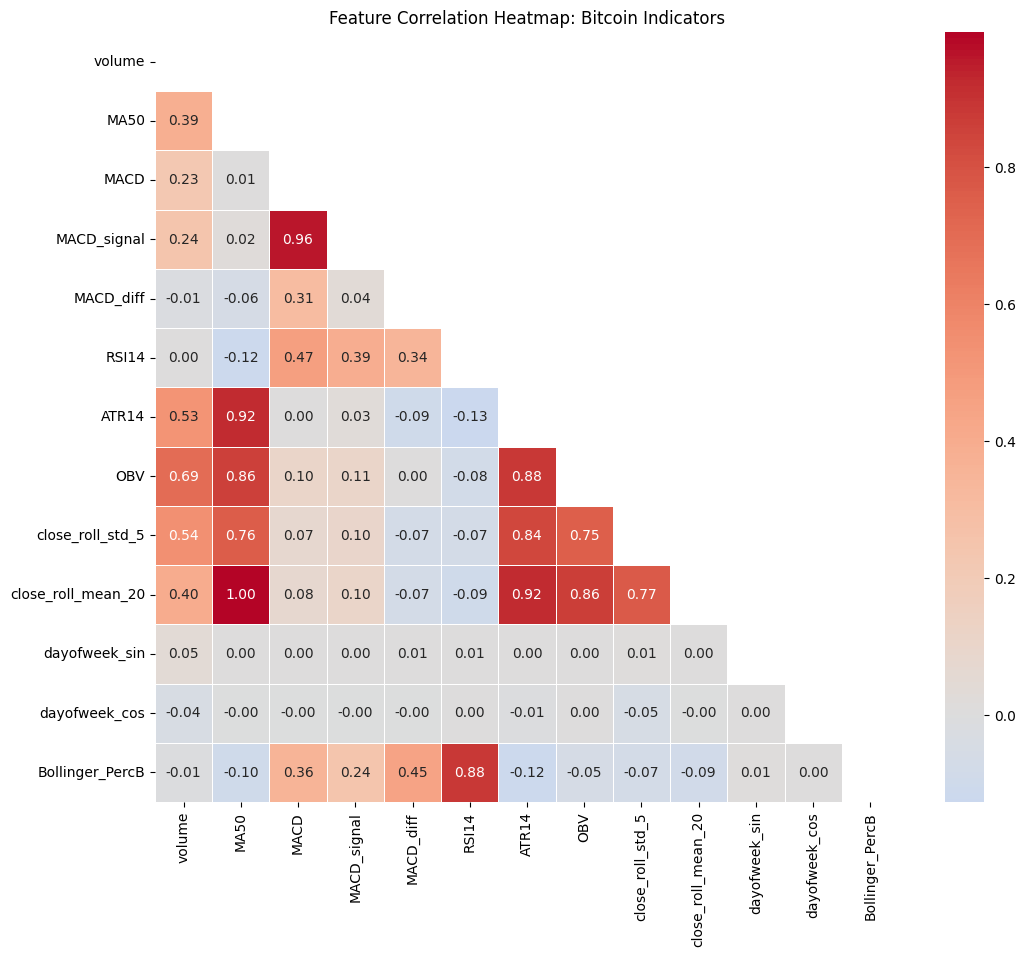

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# Assuming 'df' contains your features (RSI, Returns, MACD, etc.)
corr_matrix = df[feature_cols].corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 3. Generate a mask for the upper triangle
# (This hides the duplicate half of the map so it's easier to read)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Draw the heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Show the actual numbers
            fmt=".2f",           # Limit to 2 decimal places
            cmap='coolwarm',     # Red for positive, blue for negative corr
            center=0,            # Zero is the neutral point
            linewidths=.5)

plt.title('Feature Correlation Heatmap: Bitcoin Indicators')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


X_train_2d, X_test_2d, y_train_1d, y_test_1d = train_test_split(X, y.values, test_size=0.2, shuffle=False)
X_train_2d, X_val_2d, y_train_1d, y_val_1d = train_test_split(X_train_2d, y_train_1d, test_size=0.2, shuffle=False)

scaler = StandardScaler()
# Apply scaler to the 2D feature sets
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_val_2d_scaled = scaler.transform(X_val_2d)
X_test_2d_scaled = scaler.transform(X_test_2d)



In [ ]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])  # predict the day after the sequence
    return np.array(Xs), np.array(ys)

SEQ_LEN = 20  # number of past days to look at

# Create sequences from the *2D scaled* data
X_train_seq, y_train_seq = create_sequences(X_train_2d_scaled, y_train_1d, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test_2d_scaled, y_test_1d, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val_2d_scaled, y_val_1d, SEQ_LEN)

print(f"Train samples: {len(X_train_seq)}, Val samples: {len(X_val_seq)},  Test samples: {len(X_test_seq)}")

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(-1) # Add feature dim for target

X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(-1) # Add feature dim for target

X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32).unsqueeze(-1) # Add feature dim for target


batch_size = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Train samples: 3627, Val samples: 892,  Test samples: 1120


In [ ]:

# -----------------------------
# 5. GRU + Attention Model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class ForecastGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout, bidirectional=False)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4,
                                               batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.gru(x)                     # (batch, seq, hidden)
        out = self.dropout(out)
        attn_out, _ = self.attention(out, out, out)  # self-attention
        last_step = attn_out[:, -1, :]           # take last time step
        return self.fc(last_step).squeeze(-1)





input_dim = len(feature_cols)



model = ForecastGRU(input_dim=input_dim, hidden_dim=64, num_layers=2, dropout=0.3).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# -----------------------------
# 6. Training Loop with Early Stopping
# -----------------------------
epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0

print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))



Using device: cuda
Starting training...
Epoch  10 | Train Loss: 0.00289 | Val Loss: 0.00136
Epoch  20 | Train Loss: 0.00286 | Val Loss: 0.00137
Epoch  30 | Train Loss: 0.00286 | Val Loss: 0.00140
Early stopping at epoch 32


<All keys matched successfully>

In [ ]:
# -----------------------------
# 7. Evaluation on Validation Set
# -----------------------------
model.eval()
with torch.no_grad():
    val_preds = model(X_val_t.to(device)).cpu().numpy()
val_true = y_val_seq

# Fix 1: Introduce scaler_y for target variable (returns)
# Use y_train_1d for fitting the scaler for returns
# scaler_y = StandardScaler()
# scaler_y.fit(y_train_1d.reshape(-1, 1))

# # Inverse transform to original scale (percentage returns) using scaler_y
# val_preds = scaler_y.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
# val_true = scaler_y.inverse_transform(val_true_scaled.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(val_true, val_preds))
mae = mean_absolute_error(val_true, val_preds)
print(f"\nValidation RMSE: {rmse:.4f}%")
print(f"Validation MAE: {mae:.4f}%")

# Directional accuracy
pred_sign = np.sign(val_preds)
true_sign = np.sign(val_true)
dir_acc = np.mean(pred_sign == true_sign)
print(f"Directional accuracy: {dir_acc:.2%}")

# -----------------------------
# 8. Predict Next Day's Return
# -----------------------------
# Fix 2: X_scaled needs to be defined. It represents the entire dataset scaled.
# We need to concatenate the scaled train, validation, and test sets to get a full scaled dataset.
# The original X was split into X_train_2d, X_val_2d, X_test_2d and then scaled.
# So, X_scaled should be a concatenation of X_train_2d_scaled, X_val_2d_scaled, and X_test_2d_scaled.
X_scaled = np.concatenate((X_train_2d_scaled, X_val_2d_scaled, X_test_2d_scaled))

# Get the last SEQ_LEN days from the scaled data
last_sequence = X_scaled[-SEQ_LEN:]   # shape (SEQ_LEN, input_dim)
last_tensor = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

# model.eval()
# with torch.no_grad():
#     next_pred_scaled = model(last_tensor).cpu().numpy().flatten()[0]
# next_return = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]

# print(f"\nPredicted next day's return: {next_return:.4f}%")
# print("(Positive = price increase expected, Negative = decrease expected)")

# Optional: Save predictions to CSV
results = pd.DataFrame({
    'true_return': val_true,
    'predicted_return': val_preds
})
results.to_csv('predictions.csv', index=False)
print("\nValidation predictions saved to 'predictions.csv'")


Validation RMSE: 0.0370%
Validation MAE: 0.0264%
Directional accuracy: 47.76%

Validation predictions saved to 'predictions.csv'


In [ ]:
model.eval()
test_loss = 0.0
all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_preds.append(preds.cpu().numpy())
test_loss /= len(test_loader.dataset)
test_preds = np.concatenate(all_preds)
test_true = y_test_seq

rmse = np.sqrt(mean_squared_error(test_true, test_preds))
mae = mean_absolute_error(test_true, test_preds)
print(f"Test RMSE: {rmse:.4f} (absolute return)")
print(f"Test MAE: {mae:.4f}")



Test RMSE: 0.0264 (absolute return)
Test MAE: 0.0192


In [ ]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t.to(device)).cpu().numpy() # Predict once for the entire test tensor
test_true = y_test_seq # The true targets for the entire test sequence

rmse = np.sqrt(mean_squared_error(test_true, test_preds))
mae = mean_absolute_error(test_true, test_preds)
print(f"\nTest RMSE: {rmse:.4f}%")
print(f"Test MAE: {mae:.4f}%") # Changed 'Validation MAE' to 'Test MAE' for clarity


Test RMSE: 0.0264%
Test MAE: 0.0192%


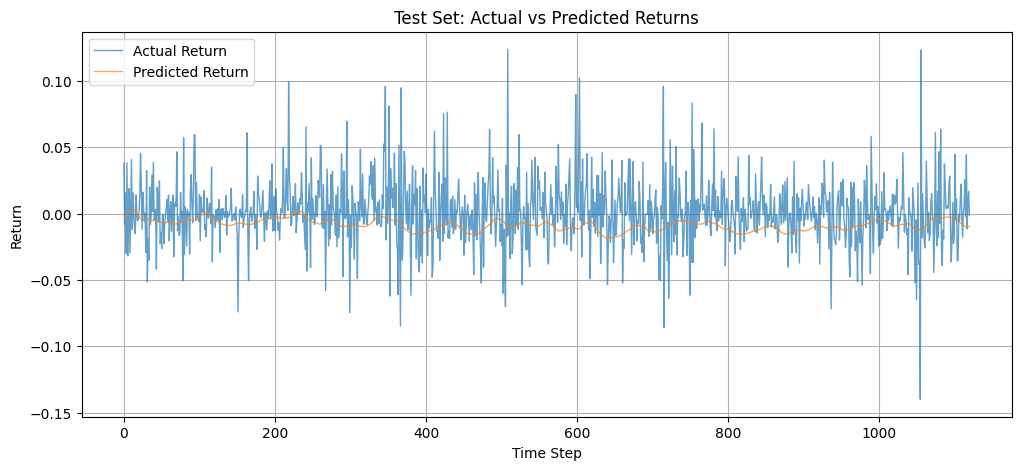

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(test_true, label='Actual Return', alpha=0.7, linewidth=1)
plt.plot(test_preds, label='Predicted Return', alpha=0.7, linewidth=1)
plt.title('Test Set: Actual vs Predicted Returns')
plt.xlabel('Time Step')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

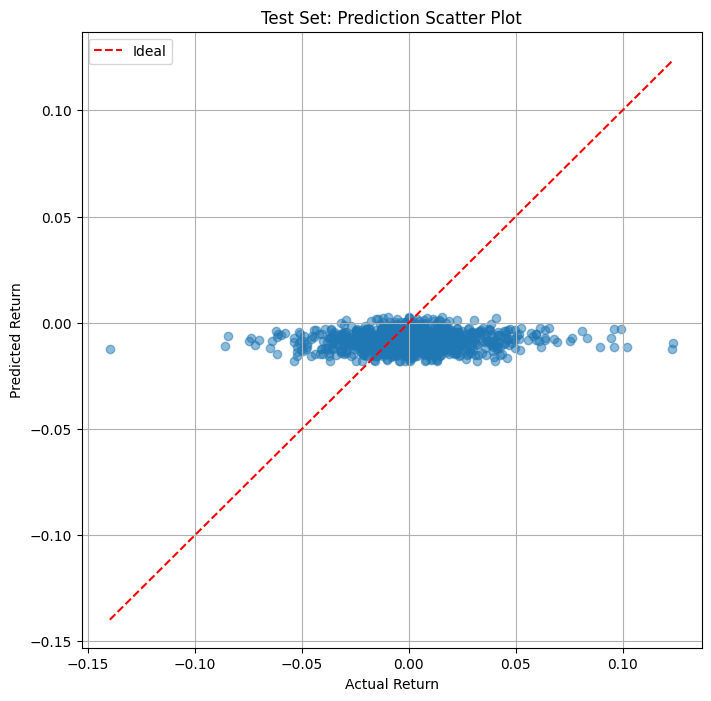

In [ ]:
# Optional: Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(test_true, test_preds, alpha=0.5)
min_val = min(np.min(test_true), np.min(test_preds))
max_val = max(np.max(test_true), np.max(test_preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.xlabel('Actual Return')
plt.ylabel('Predicted Return')
plt.title('Test Set: Prediction Scatter Plot')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predic = pd.read_csv('predictions.csv')
predic.head()

,true_return,predicted_return
0,-0.001596,-0.002317
1,0.014645,-0.002041
2,-0.014640,-0.001885
3,-0.044601,-0.001745
4,0.009923,-0.001826
